# Pebble DB Metrics Visualization

This notebook visualizes database metrics from Samurai benchmark runs.

**Metrics visualized:**
- Compaction Estimated Debt
- Flush Count
- Compaction Count
- Total DB Size
- L0 Files
- MemTable Size

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
plt.style.use('default')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

In [21]:
# === CONFIGURE THIS ===
DB_METRICS_FILE = "../../benchmark_output/bench_db_metrics_20260106_202012.csv"
WARMUP_SECONDS = 0
COOLDOWN_SECONDS = 0
# ======================

In [22]:
def load_and_prepare_data(filepath, warmup_s, cooldown_s):
    """Load DB metrics and prepare for visualization."""
    df = pd.read_csv(filepath)
    
    # Convert units
    df["timestamp_s"] = df["timestamp_ns"] / 1e9
    df["compact_estimated_debt_mb"] = df["compact_estimated_debt"] / (1024 * 1024)
    df["l0_size_mb"] = df["l0_size"] / (1024 * 1024)
    df["total_size_mb"] = df["total_size"] / (1024 * 1024)
    df["memtable_size_mb"] = df["memtable_size"] / (1024 * 1024)
    
    # Trim warmup/cooldown
    min_time = df["timestamp_s"].min()
    max_time = df["timestamp_s"].max()
    start_time = min_time + warmup_s
    end_time = max_time - cooldown_s
    
    df = df[(df["timestamp_s"] >= start_time) & (df["timestamp_s"] <= end_time)].copy()
    df["time_normalized"] = df["timestamp_s"] - start_time
    
    return df

# Load data
df = load_and_prepare_data(DB_METRICS_FILE, WARMUP_SECONDS, COOLDOWN_SECONDS)
print(f"Loaded {len(df)} samples")

# Get shard info
if "shard_id" in df.columns:
    shard_ids = sorted(df["shard_id"].unique())
    num_shards = len(shard_ids)
    print(f"Found {num_shards} shards")
else:
    shard_ids = []
    num_shards = 0
    print("No per-shard data available")

Loaded 9664 samples
Found 32 shards


In [23]:
def aggregate_all_shards(df):
    """Aggregate metrics across all shards."""
    if "shard_id" not in df.columns:
        return df
    
    agg = df.groupby("timestamp_ns").agg({
        "time_normalized": "first",
        "compact_count": "sum",
        "compact_estimated_debt_mb": "sum",
        "compact_num_in_progress": "sum",
        "flush_count": "sum",
        "memtable_size_mb": "sum",
        "l0_num_files": "sum",
        "total_size_mb": "sum",
    }).reset_index()
    
    return agg

df_agg = aggregate_all_shards(df)
print(f"Aggregated to {len(df_agg)} time points")

Aggregated to 302 time points


## Aggregated Metrics (All Shards)

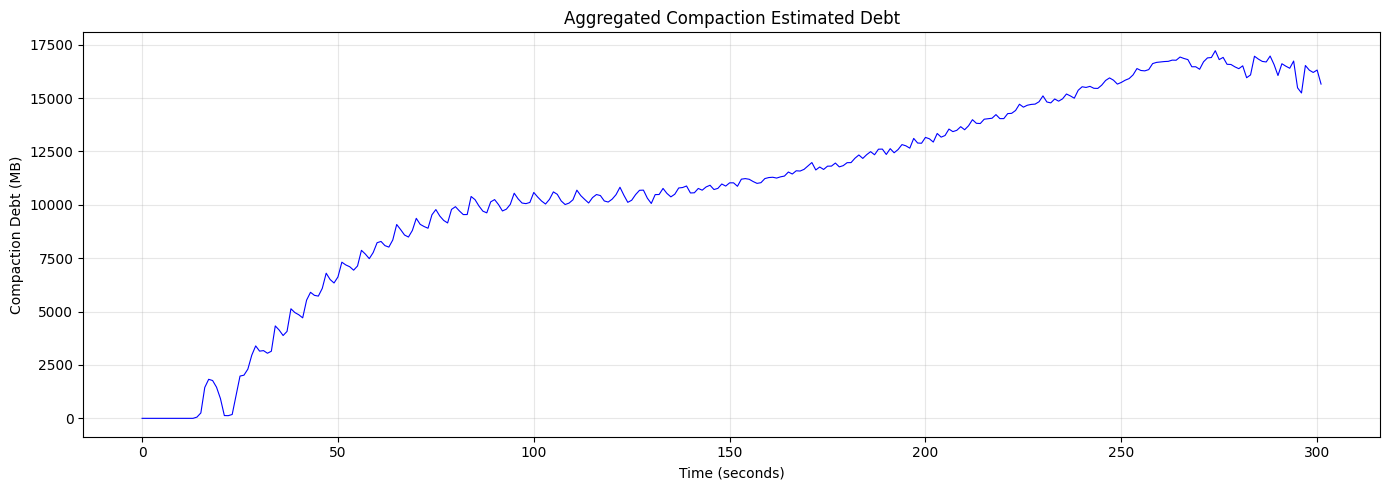

In [24]:
# Aggregated: Compaction Debt
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["compact_estimated_debt_mb"], 'b-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Compaction Debt (MB)")
plt.title("Aggregated Compaction Estimated Debt")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

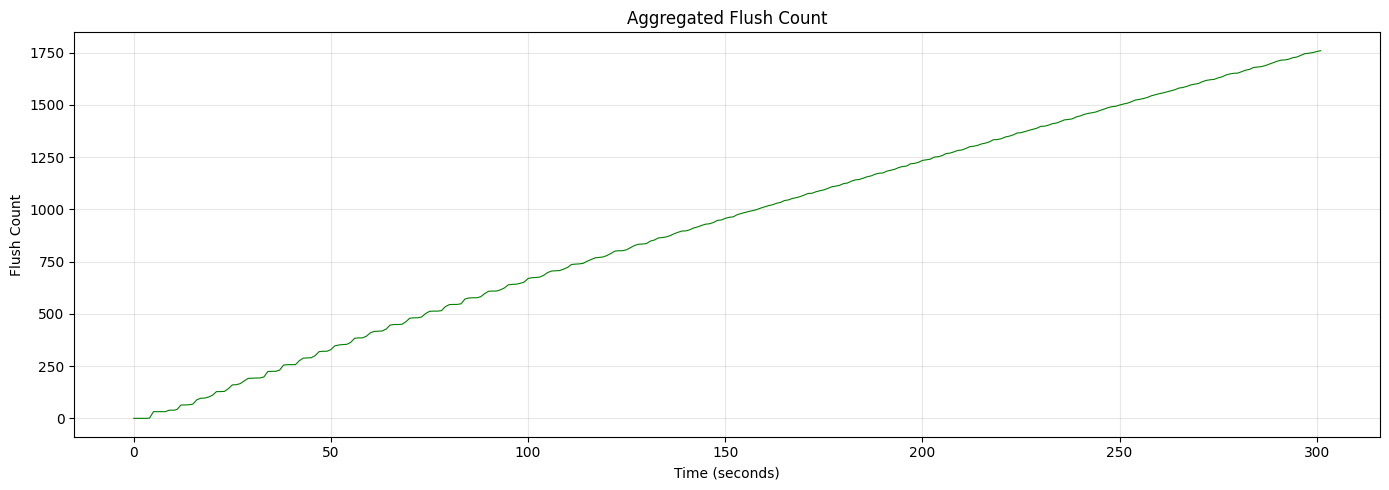

In [25]:
# Aggregated: Flush Count
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["flush_count"], 'g-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Flush Count")
plt.title("Aggregated Flush Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

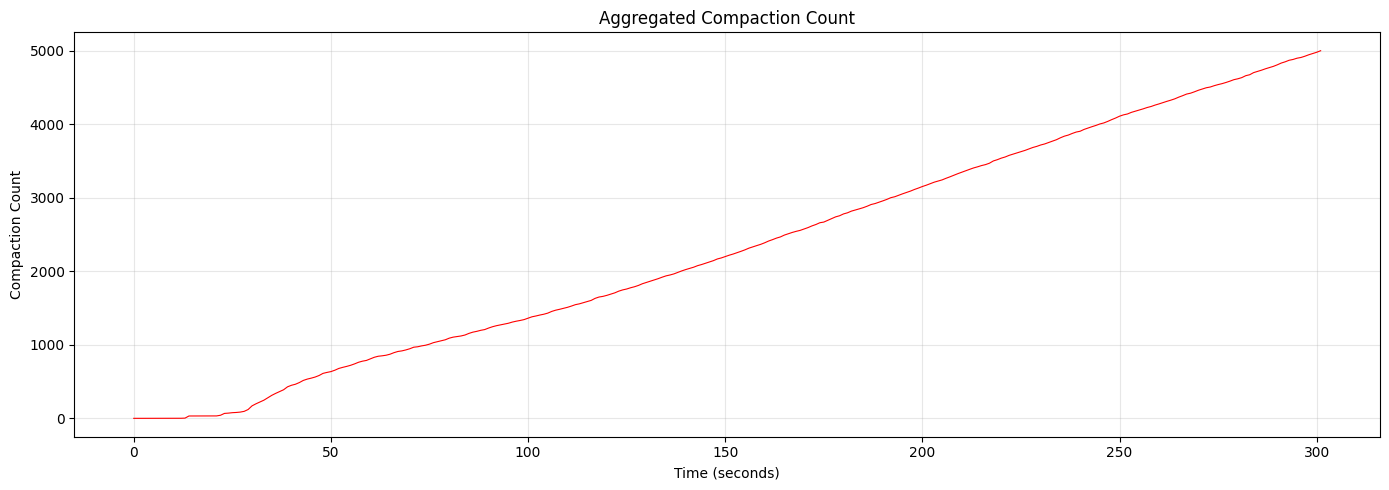

In [26]:
# Aggregated: Compaction Count
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["compact_count"], 'r-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Compaction Count")
plt.title("Aggregated Compaction Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

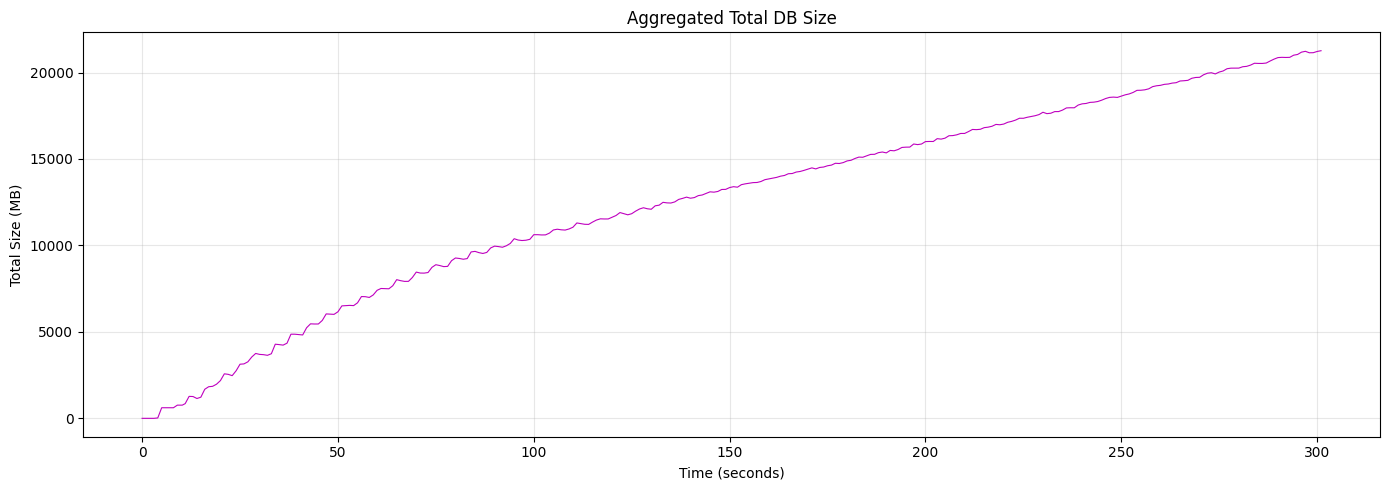

In [27]:
# Aggregated: Total DB Size
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["total_size_mb"], 'm-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Total Size (MB)")
plt.title("Aggregated Total DB Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

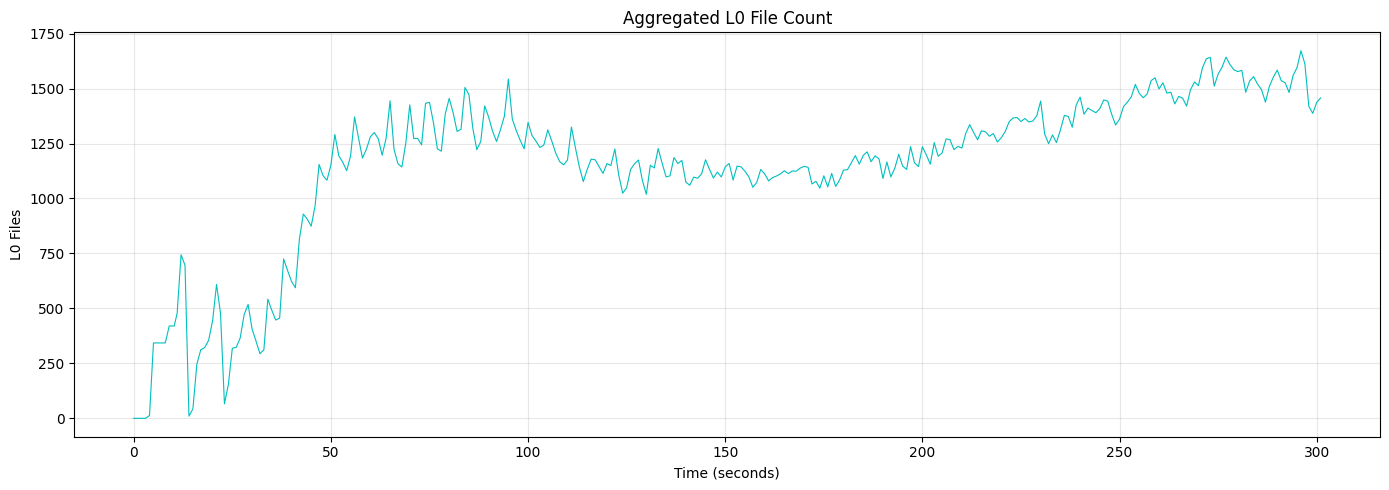

In [28]:
# Aggregated: L0 Files
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["l0_num_files"], 'c-', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("L0 Files")
plt.title("Aggregated L0 File Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

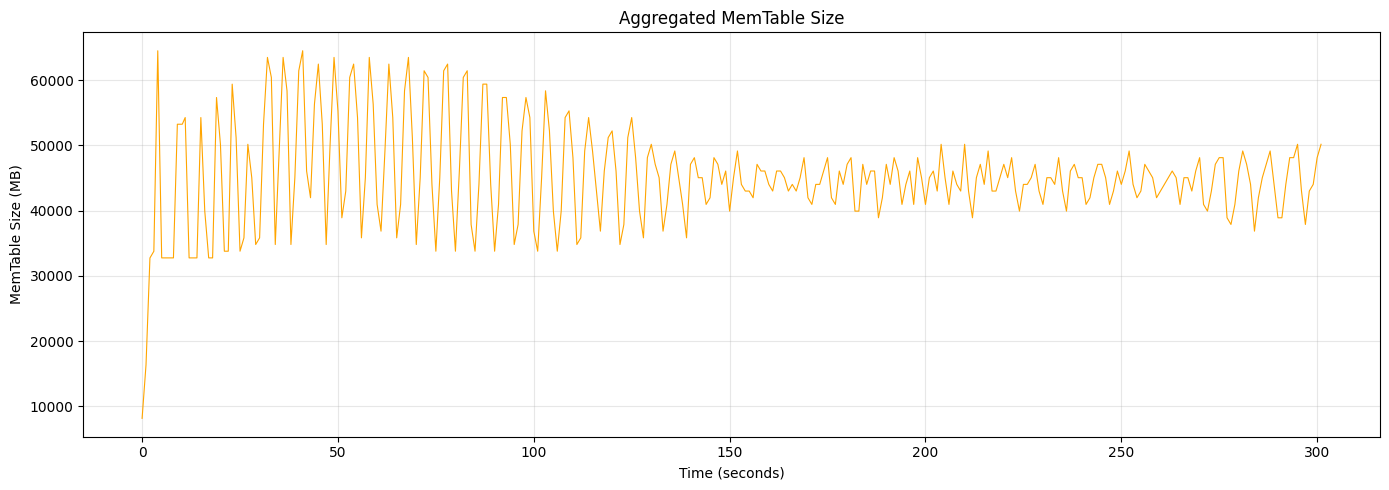

In [29]:
# Aggregated: MemTable Size
plt.figure(figsize=(14, 5))
plt.plot(df_agg["time_normalized"], df_agg["memtable_size_mb"], 'orange', linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("MemTable Size (MB)")
plt.title("Aggregated MemTable Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Shard Metrics

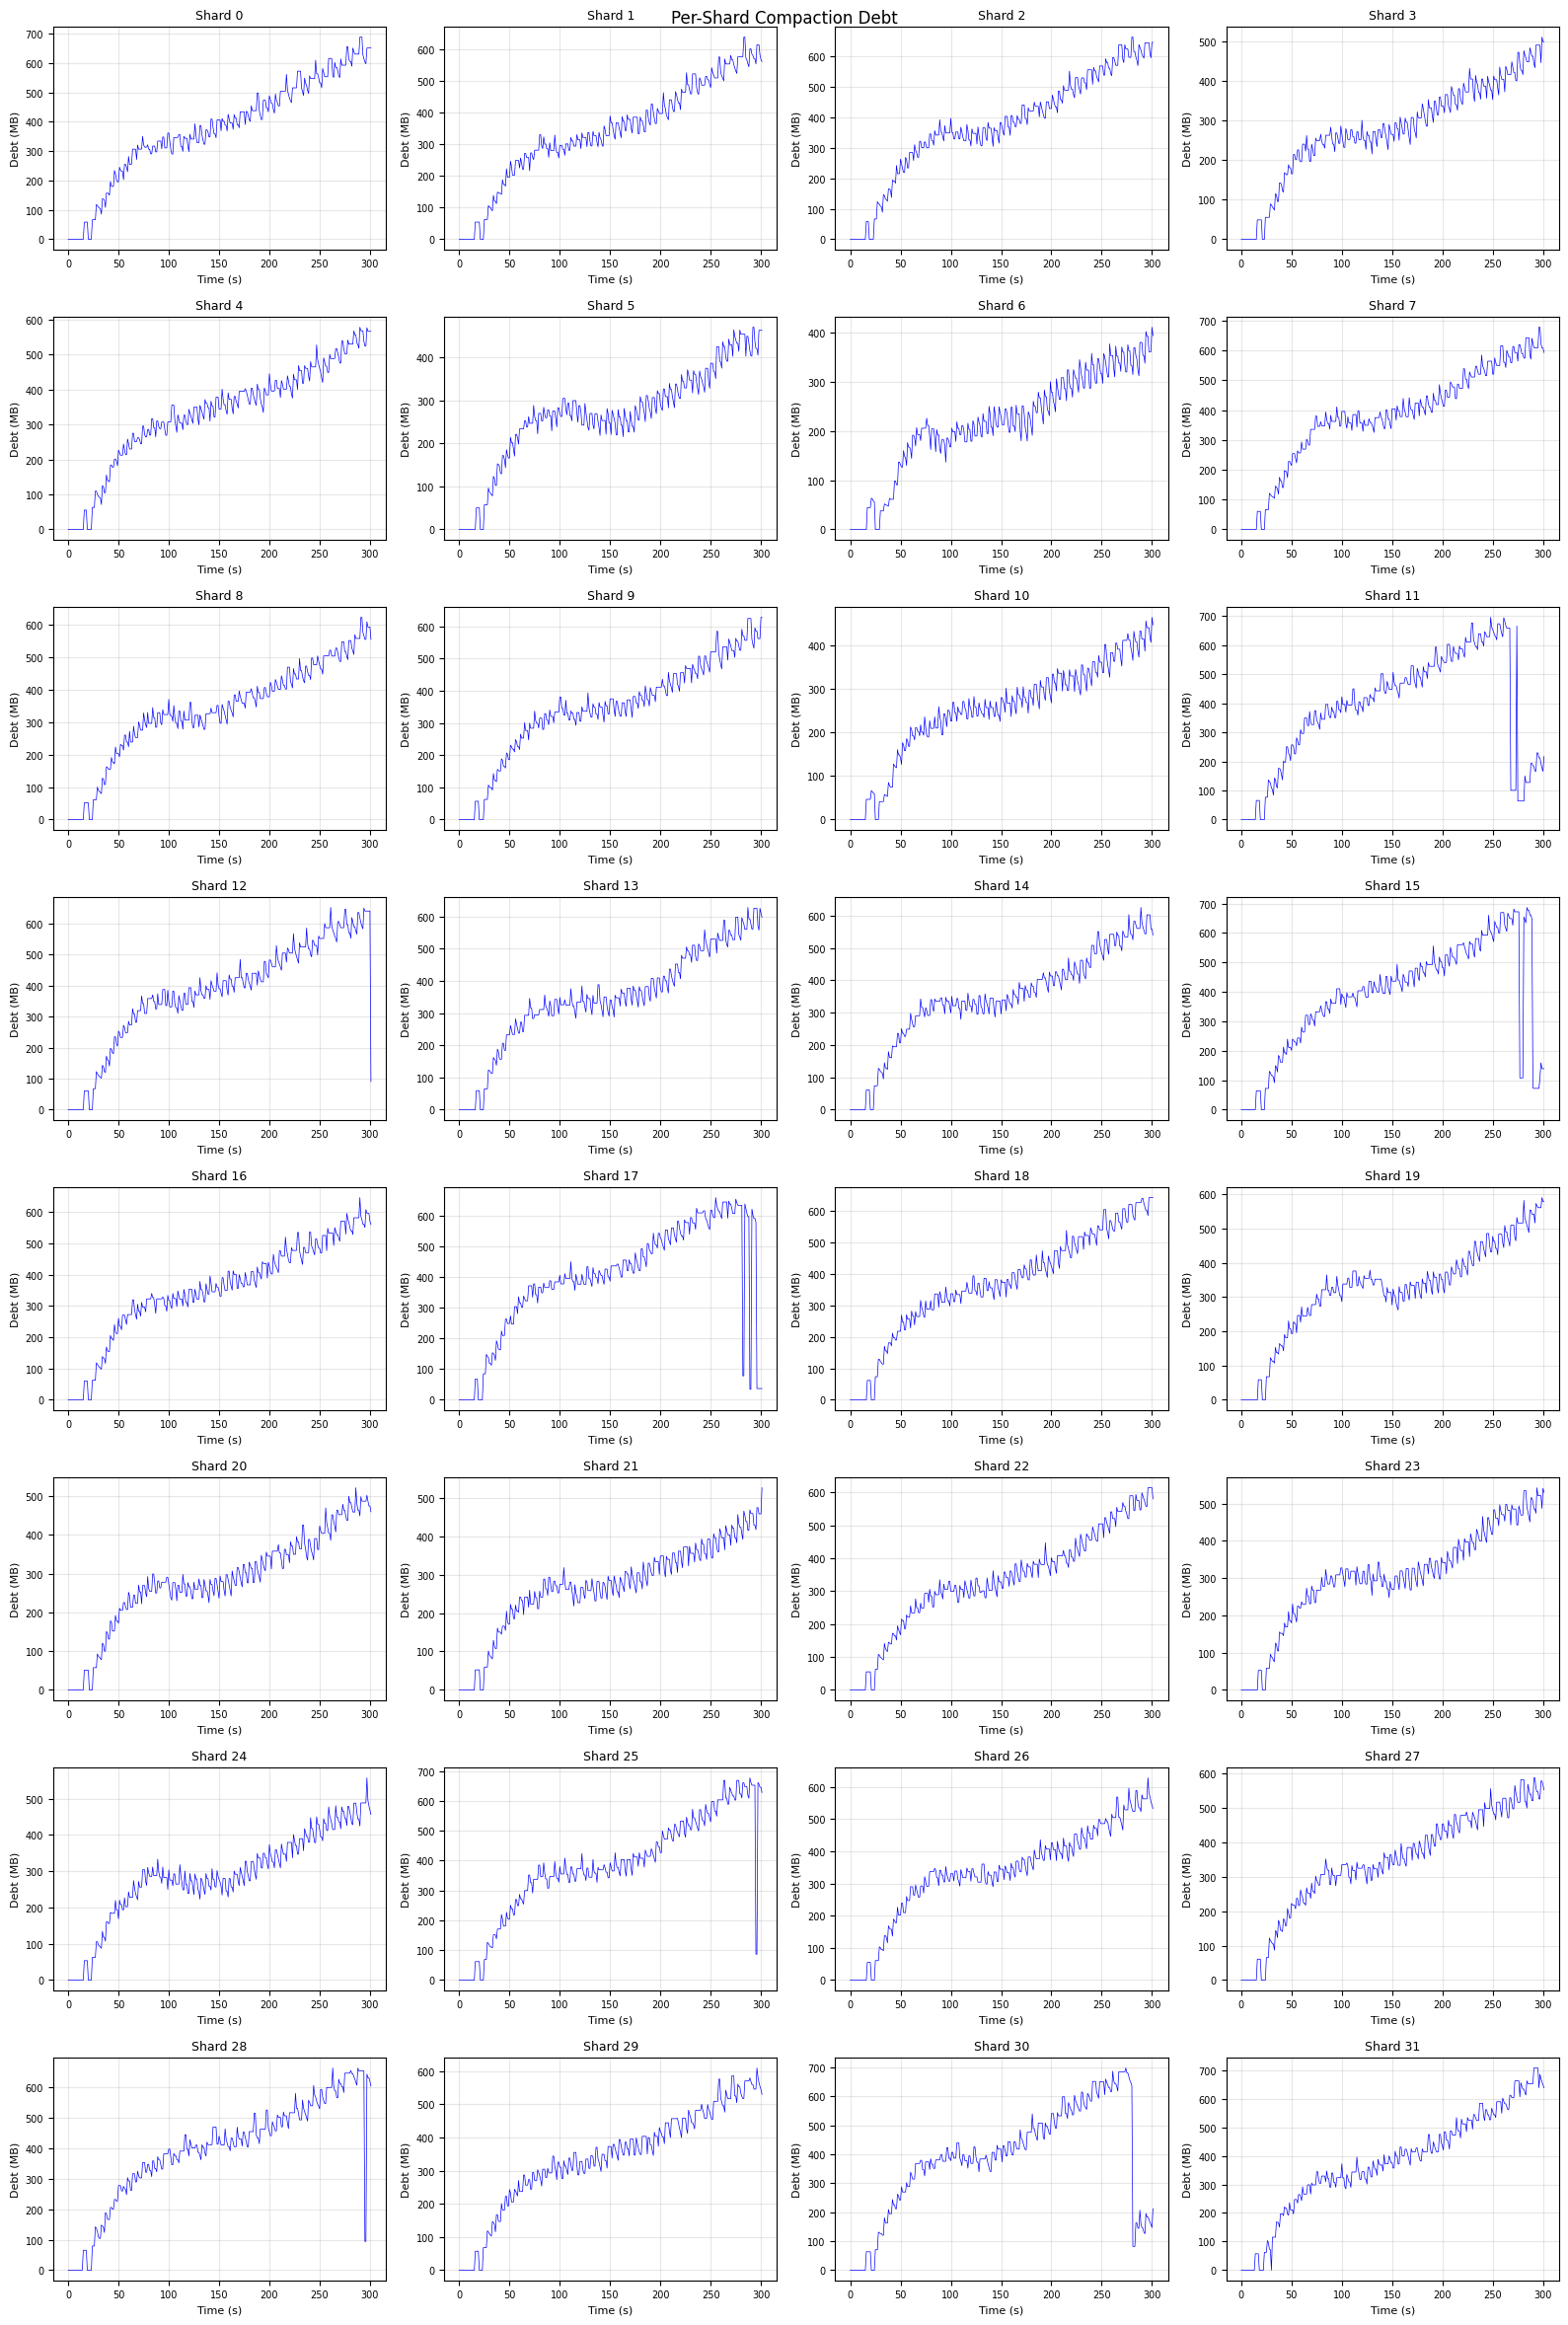

In [30]:
# Per-Shard: Compaction Debt (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["compact_estimated_debt_mb"], 'b-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Debt (MB)", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Compaction Debt", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")

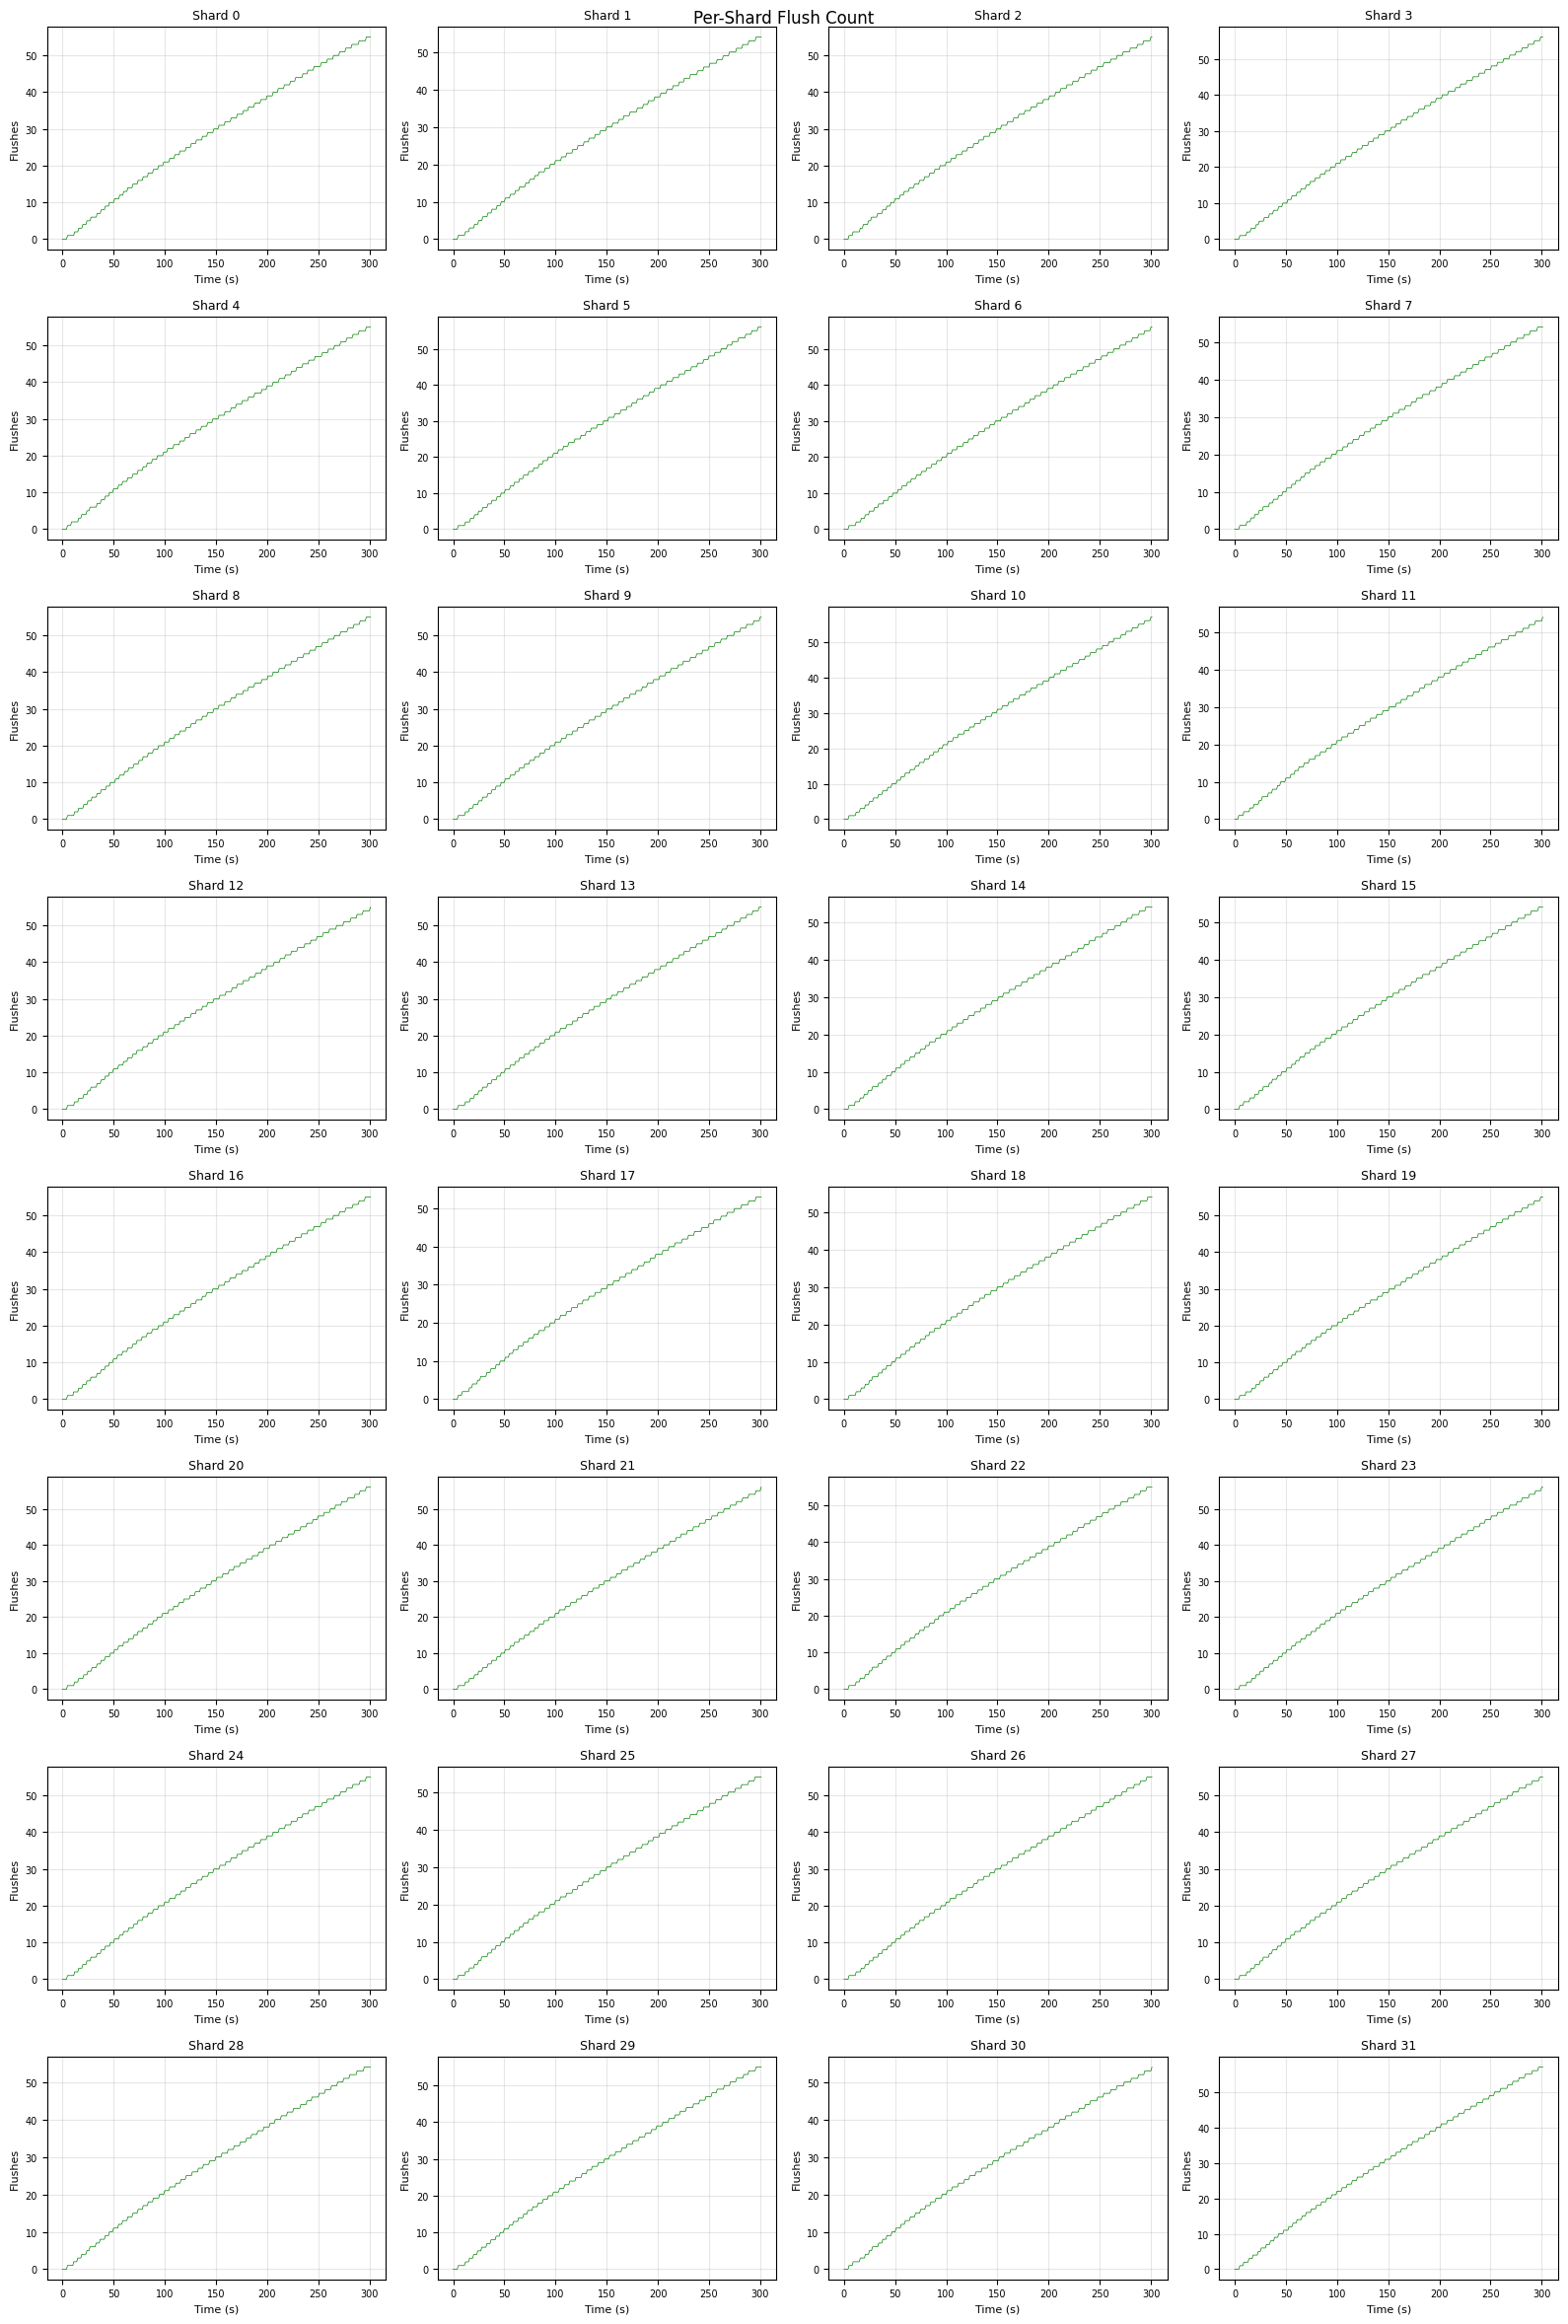

In [31]:
# Per-Shard: Flush Count (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["flush_count"], 'g-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Flushes", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Flush Count", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")

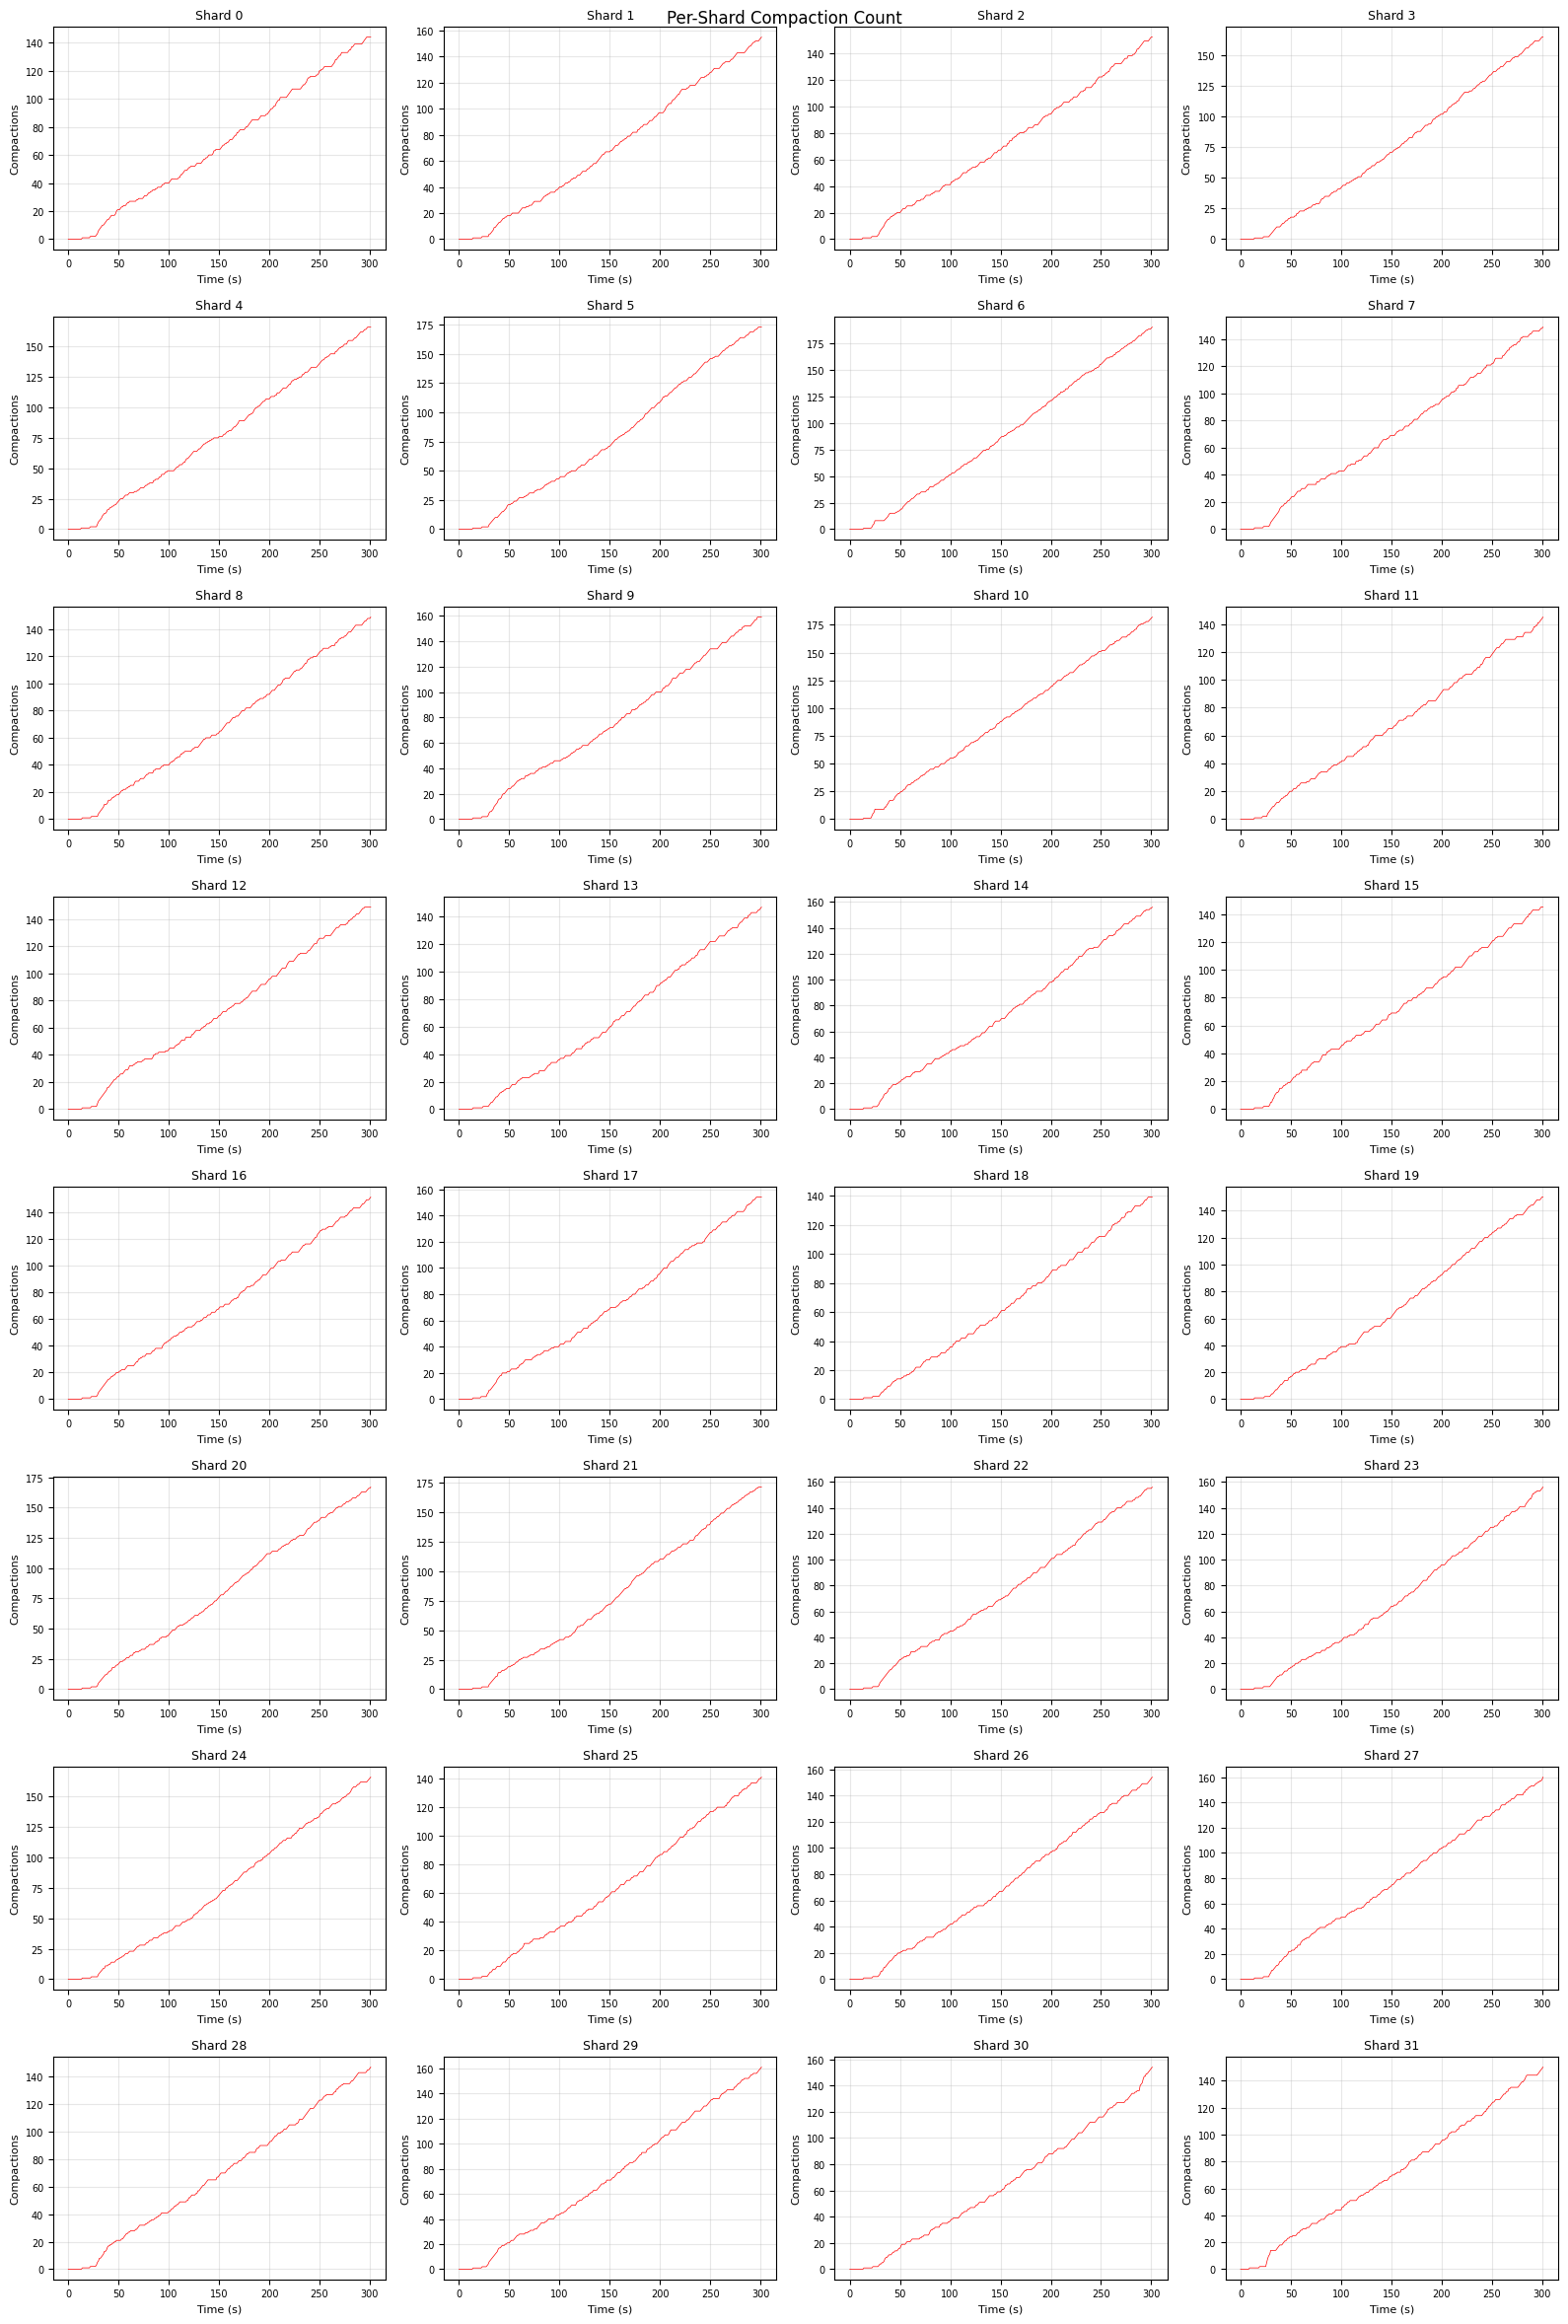

In [32]:
# Per-Shard: Compaction Count (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["compact_count"], 'r-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Compactions", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Compaction Count", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")

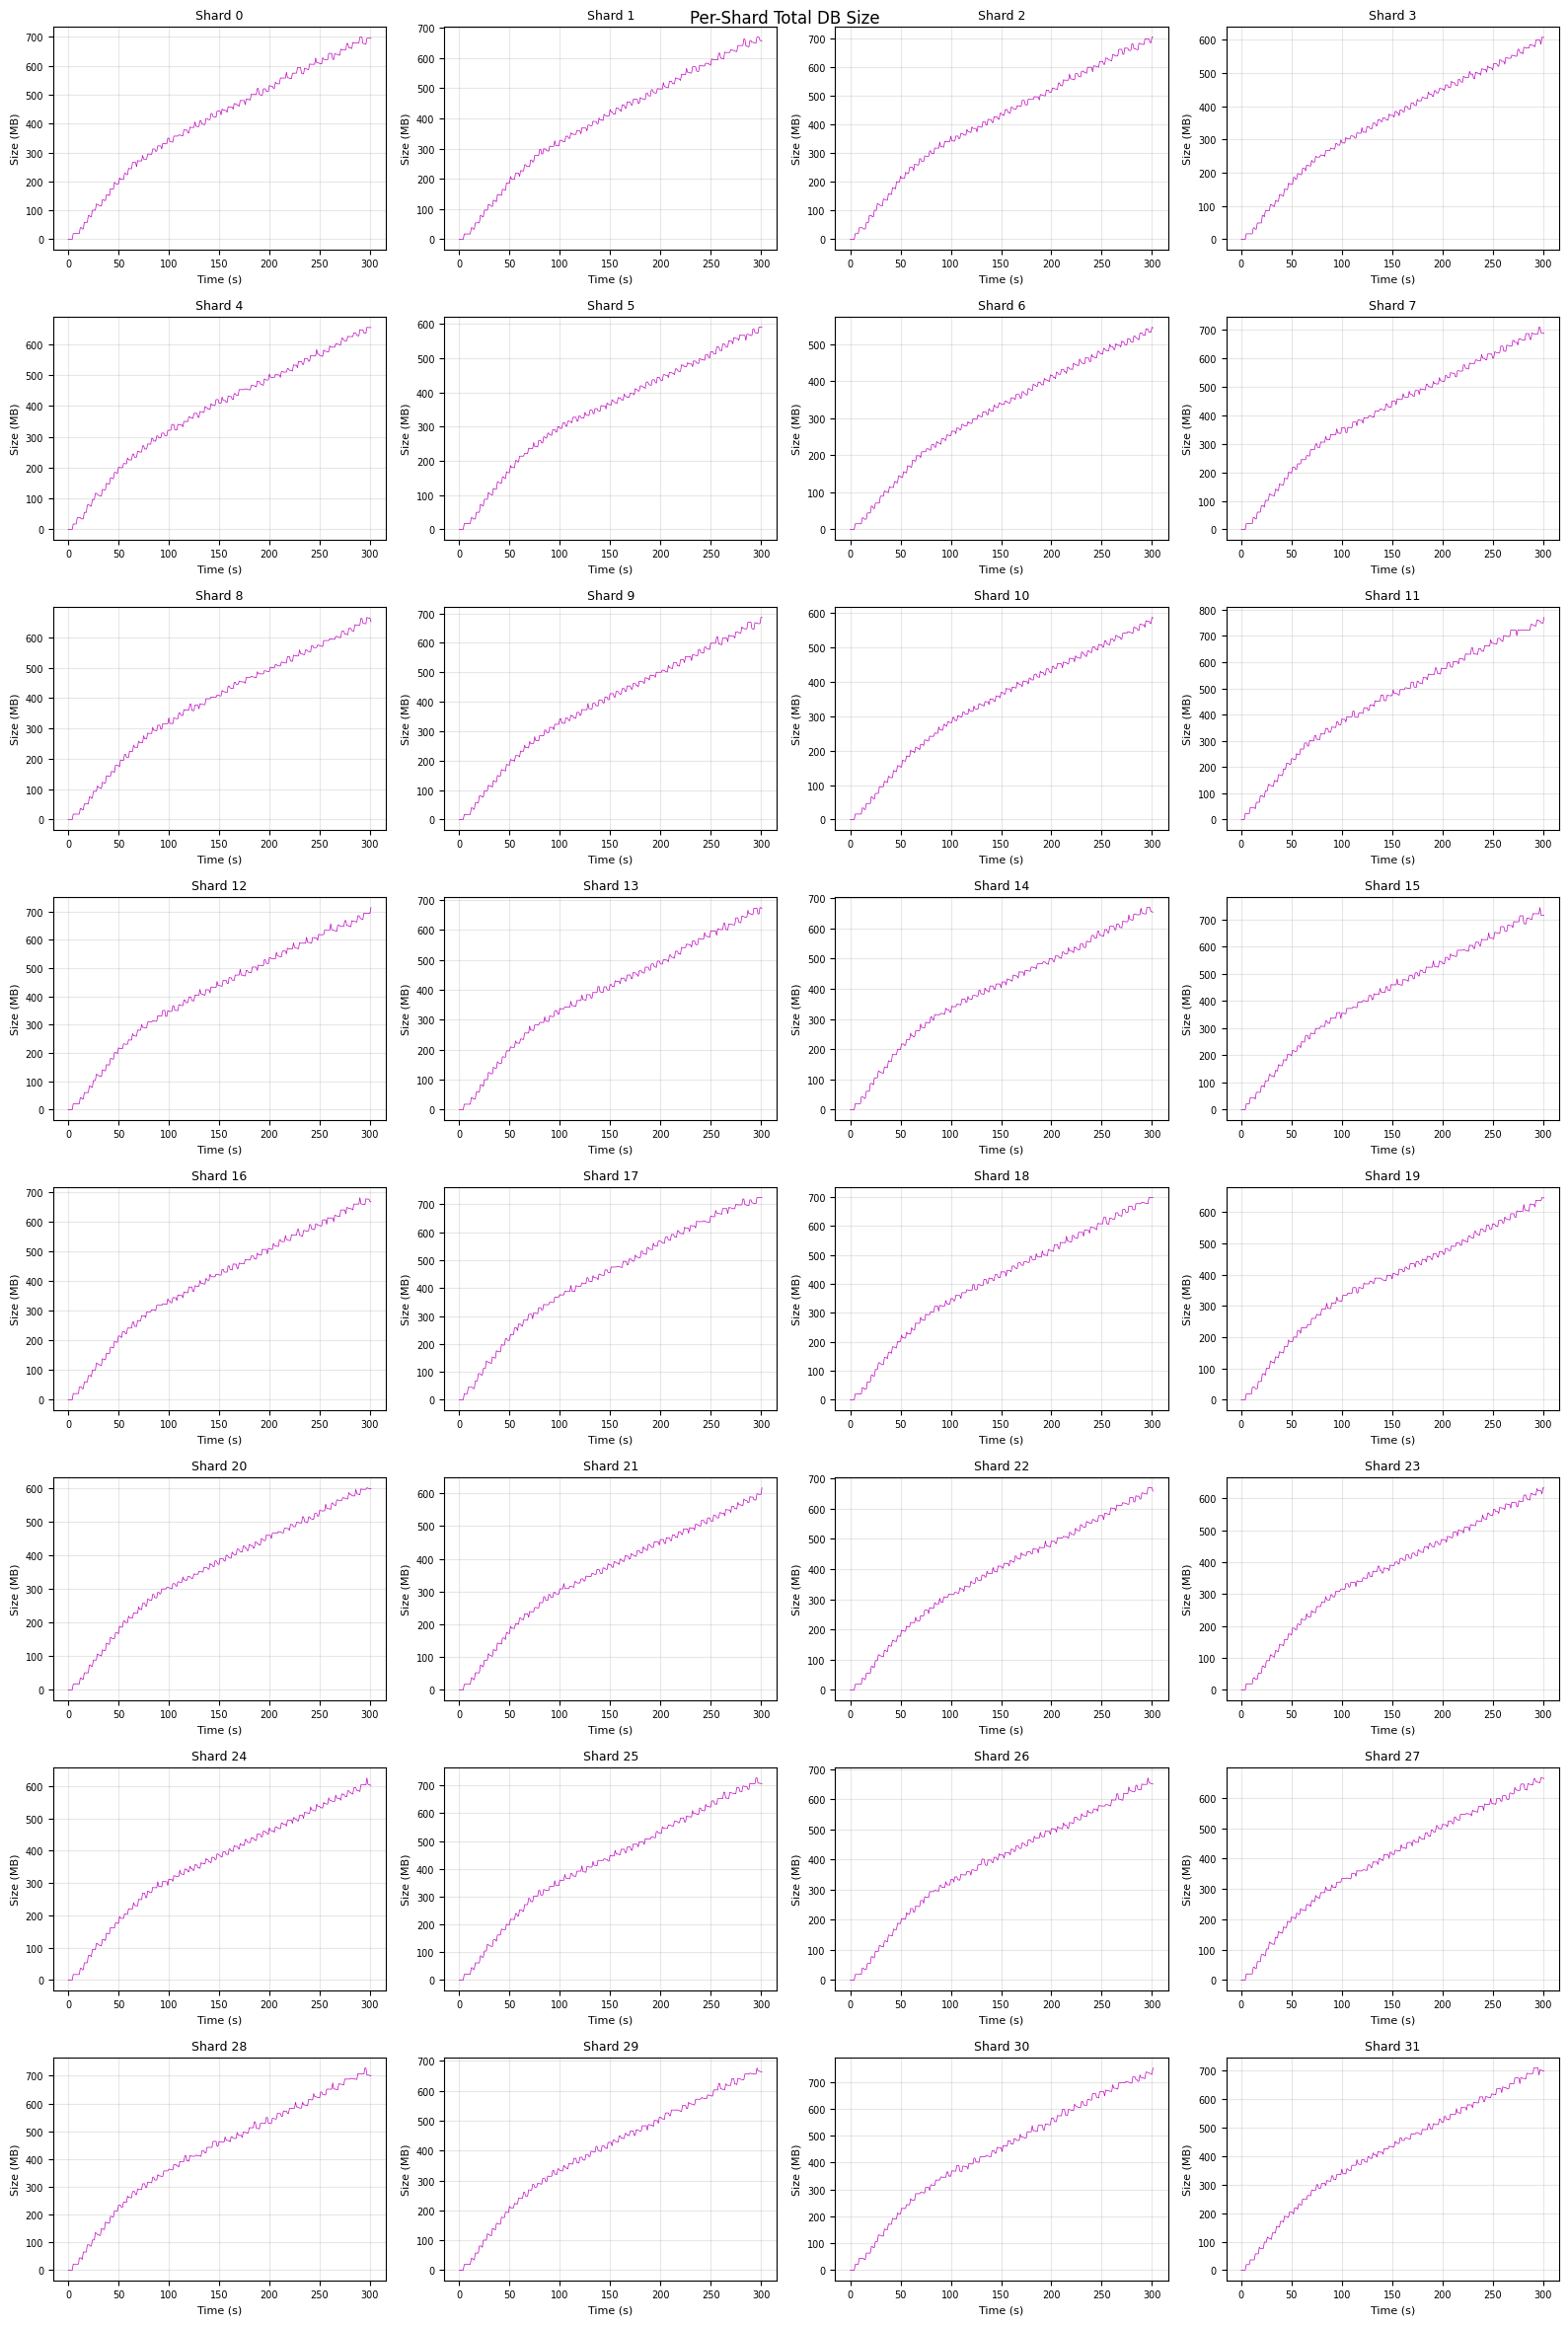

In [33]:
# Per-Shard: Total DB Size (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["total_size_mb"], 'm-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("Size (MB)", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard Total DB Size", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")

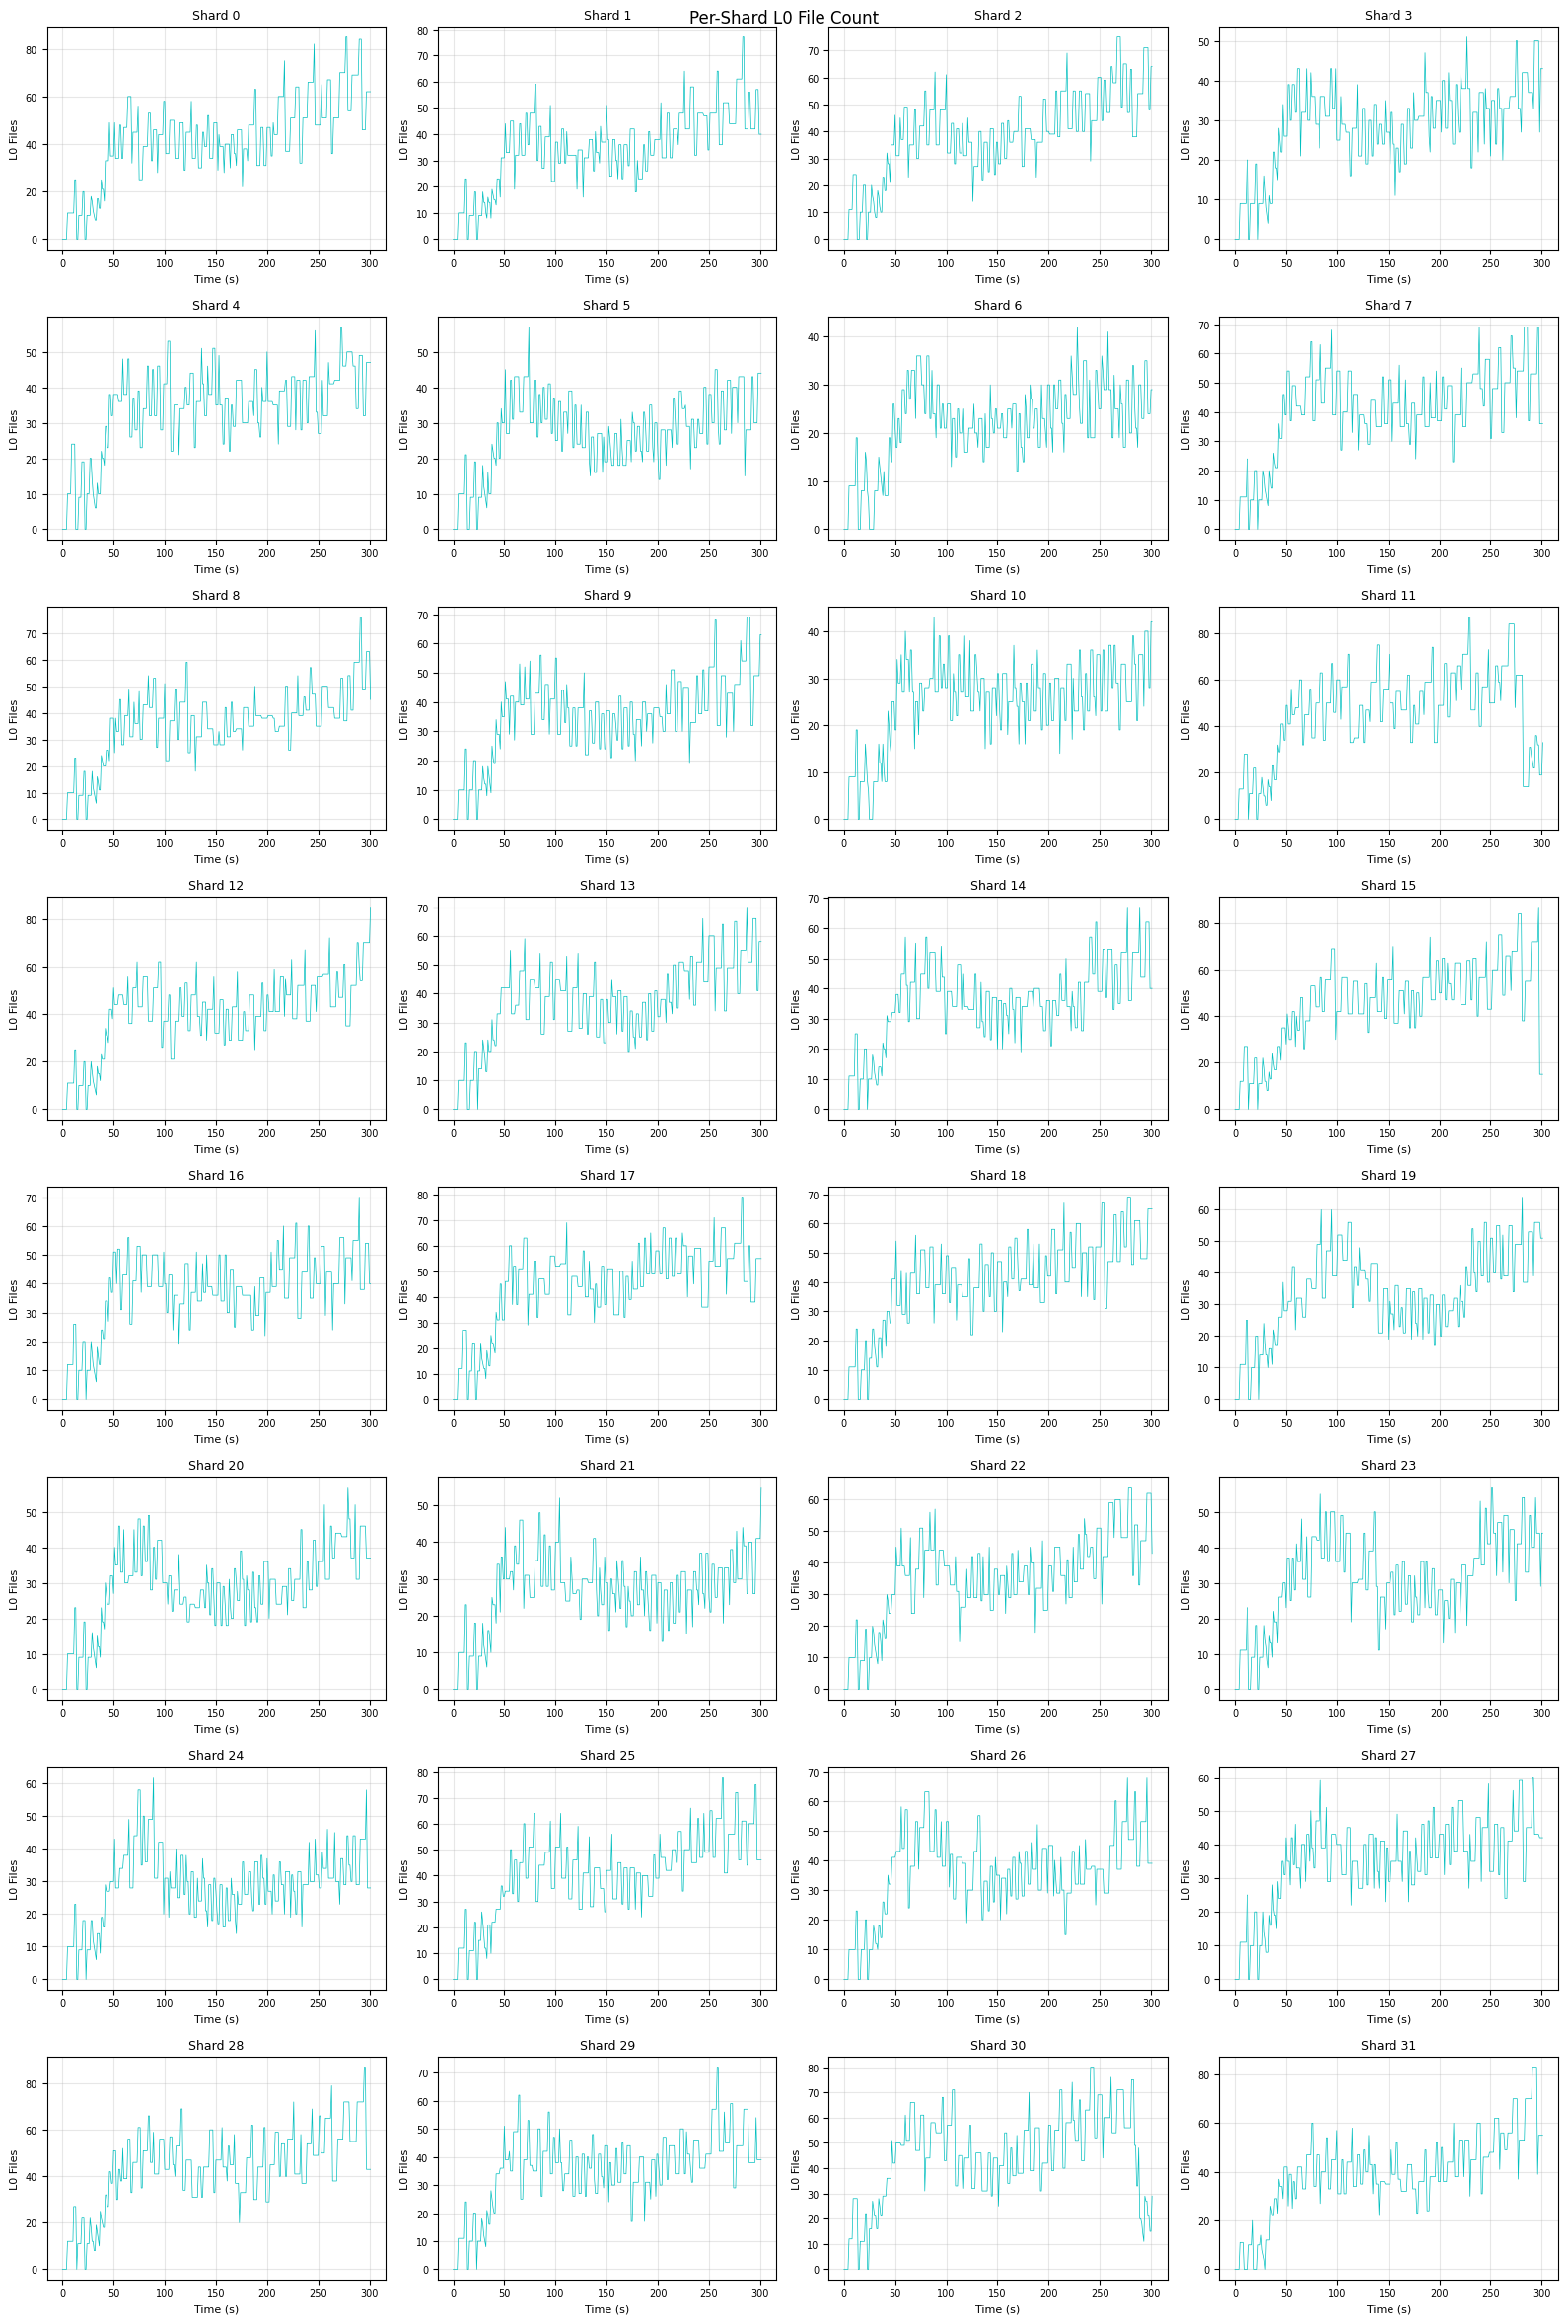

In [34]:
# Per-Shard: L0 Files (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["l0_num_files"], 'c-', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("L0 Files", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard L0 File Count", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")

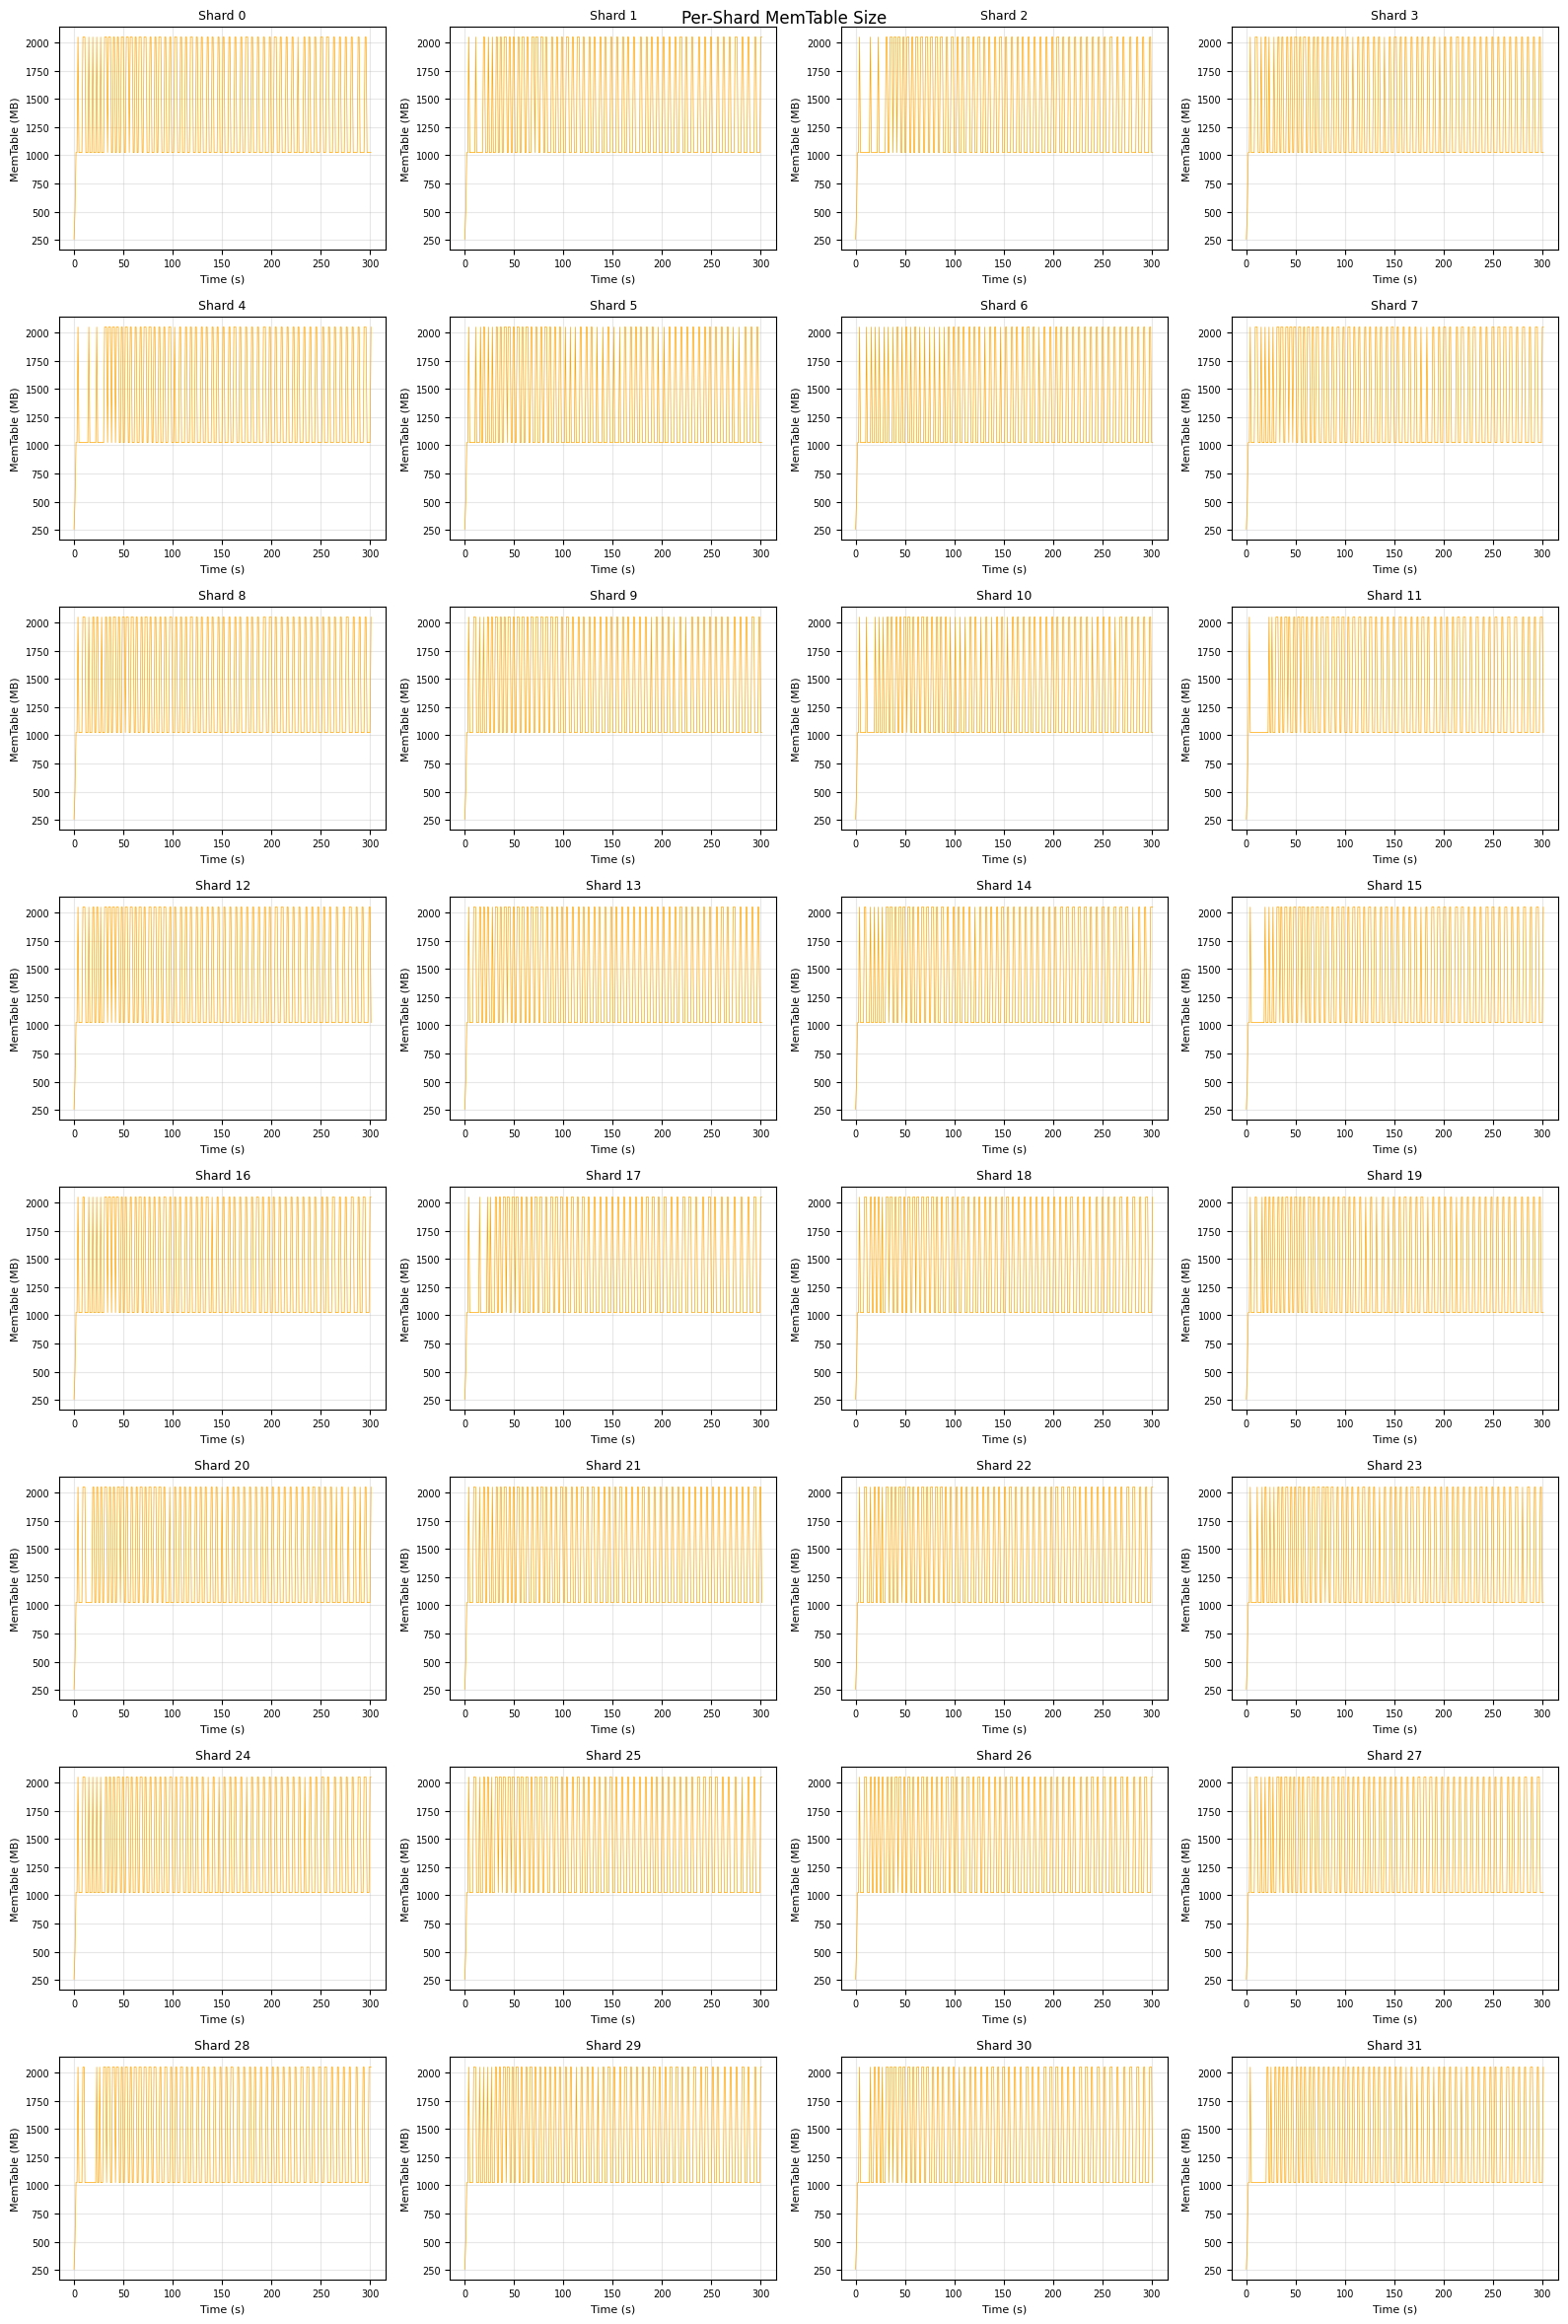

In [35]:
# Per-Shard: MemTable Size (individual plots)
if num_shards > 0:
    cols = 4
    rows = (num_shards + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3 * rows))
    axes = axes.flatten() if num_shards > 1 else [axes]
    
    for idx, shard_id in enumerate(shard_ids):
        shard_df = df[df["shard_id"] == shard_id]
        axes[idx].plot(shard_df["time_normalized"], shard_df["memtable_size_mb"], 'orange', linewidth=0.5)
        axes[idx].set_title(f"Shard {shard_id}", fontsize=9)
        axes[idx].set_xlabel("Time (s)", fontsize=8)
        axes[idx].set_ylabel("MemTable (MB)", fontsize=8)
        axes[idx].tick_params(labelsize=7)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(num_shards, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle("Per-Shard MemTable Size", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No per-shard data available")

In [36]:
## Summary Statistics

# Aggregated summary statistics
print("=" * 70)
print("Aggregated DB Metrics Summary")
print("=" * 70)
print(f"{'Metric':<40} {'Min':>10} {'Max':>10} {'Mean':>10}")
print("-" * 70)

metrics_info = [
    ("Compaction Debt (MB)", "compact_estimated_debt_mb"),
    ("Flush Count", "flush_count"),
    ("Compaction Count", "compact_count"),
    ("Total Size (MB)", "total_size_mb"),
    ("L0 Files", "l0_num_files"),
    ("MemTable Size (MB)", "memtable_size_mb"),
]

for name, col in metrics_info:
    print(f"{name:<40} {df_agg[col].min():>10.2f} {df_agg[col].max():>10.2f} {df_agg[col].mean():>10.2f}")
print("=" * 70)

In [37]:
# Per-shard final values summary
if num_shards > 0:
    print("\n" + "=" * 100)
    print("Per-Shard Final Values")
    print("=" * 100)
    print(f"{'Shard':>5} {'Debt(MB)':>12} {'Flushes':>10} {'Compacts':>10} {'Size(MB)':>12} {'L0 Files':>10} {'MemTbl(MB)':>12}")
    print("-" * 100)
    
    for shard_id in shard_ids:
        shard_df = df[df["shard_id"] == shard_id]
        last_row = shard_df.iloc[-1]
        print(f"{shard_id:>5} {last_row['compact_estimated_debt_mb']:>12.2f} {last_row['flush_count']:>10.0f} "
              f"{last_row['compact_count']:>10.0f} {last_row['total_size_mb']:>12.2f} "
              f"{last_row['l0_num_files']:>10.0f} {last_row['memtable_size_mb']:>12.2f}")
    print("=" * 100)
else:
    print("No per-shard data available")


Per-Shard Final Values
Shard     Debt(MB)    Flushes   Compacts     Size(MB)   L0 Files   MemTbl(MB)
----------------------------------------------------------------------------------------------------
    0       651.34         55        144       695.22         62      1024.00
    1       562.67         54        155       656.50         40      2048.00
    2       646.67         55        152       705.87         64      1024.00
    3       500.12         56        165       607.47         43      1024.00
    4       566.14         55        166       654.23         47      2048.00
    5       462.68         56        173       590.50         44      1024.00
    6       393.12         56        190       544.09         29      1024.00
    7       593.57         54        149       686.50         36      2048.00
    8       554.51         55        149       651.21         45      2048.00
    9       628.19         55        159       686.55         63      1024.00
   10       448.3

In [38]:
# Per-shard statistics summary
if num_shards > 0:
    print("\n" + "=" * 100)
    print("Per-Shard Statistics (Mean Values)")
    print("=" * 100)
    print(f"{'Shard':>5} {'Debt(MB)':>12} {'Flushes':>10} {'Compacts':>10} {'Size(MB)':>12} {'L0 Files':>10} {'MemTbl(MB)':>12}")
    print("-" * 100)
    
    for shard_id in shard_ids:
        shard_df = df[df["shard_id"] == shard_id]
        print(f"{shard_id:>5} {shard_df['compact_estimated_debt_mb'].mean():>12.2f} {shard_df['flush_count'].mean():>10.0f} "
              f"{shard_df['compact_count'].mean():>10.0f} {shard_df['total_size_mb'].mean():>12.2f} "
              f"{shard_df['l0_num_files'].mean():>10.0f} {shard_df['memtable_size_mb'].mean():>12.2f}")
    print("=" * 100)
else:
    print("No per-shard data available")


Per-Shard Statistics (Mean Values)
Shard     Debt(MB)    Flushes   Compacts     Size(MB)   L0 Files   MemTbl(MB)
----------------------------------------------------------------------------------------------------
    0       378.35         29         68       411.99         42      1423.25
    1       342.28         29         71       392.12         35      1402.91
    2       376.15         29         70       413.92         39      1416.47
    3       279.94         29         75       352.47         29      1392.74
    4       332.31         29         78       385.76         34      1399.52
    5       267.45         29         79       348.43         28      1362.22
    6       218.27         29         88       316.70         22      1338.49
    7       380.37         29         71       414.23         40      1440.21
    8       335.24         29         69       387.06         35      1423.25
    9       344.82         29         75       394.26         35      1416.47
   10